# INFO-4604/5604 HW2: Linear Classification 

### Solution by: *Ryan Erickson*


## Assignment overview

News agencies, governments and corporations sometimes track social media during natural disasters to try to monitor unfolding events. But because no single person or group of people can read all available Twitter data, organizations may turn to natural language processing methods to try and understand what is happening as disasters unfold. 

While this approach is powerful, inferring events from NLP can be tricky. For instance, say a person [tweets](https://twitter.com/AnyOtherAnnaK/status/629195955506708480) that "LOOK AT THE SKY LAST NIGHT IT WAS ABLAZE." This tweet includes the word "ablaze", which may signal to a computer that there is an unfolding disaster. However, in this particular case, the person is speaking metaphorically. A simple computer system using keywords (e.g. ablaze) might be fooled into thinking the tweet is reporting an actual fire.

In this assignment, you will predict if a given tweet actually refers to a natural disaster. This exercise is motivated by real-world disaster monitoring systems, and can help you to gain practice with supervised binary classification and natural language processing.

__Note__: This dataset originally comes from [Kaggle](https://www.kaggle.com/c/nlp-getting-started/overview). But it has been modified for this problem set. Information about the data from this problem set that you find on Kaggle will almost certainly be wrong.

### What to hand in

You will submit the assignment on Canvas. Submit a single Jupyter notebook named `hw2lastname.ipynb`, where lastname is replaced with your last name. **Please also submit a PDF or HTML version of your notebook to Canvas**.

Please clearly mark all deliverables. You are encouraged to create additional cells in whatever way makes the presentation more organized and easy to follow. You are allowed to import additional Python libraries.

### Submission policies

- **Collaboration:** You are allowed to work with one partner. You are still expected to write up your own solution. Each individual must turn in their own submission, and list your collaborators after your name.
- **Late submissions:** Each student may use up to 5 late days over the semester. You have late days, not late hours. This means that if your submission is late by any amount of time past the deadline, then this will use up a late day. If it is late by any amount beyond 24 hours past the deadline, then this will use a second late, and so on. Once you have used up all late days, late assignments will be given at most 80% credit after one day and 60% credit after two days.


## Getting started

In this assignment, you will experiment with perceptron and logistic regression in `sklearn`. Much of the code has already been written for you. We will use a class called `SGDClassifier` (which you should read about in the [sklearn documentation](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)), which  implements stochastic gradient descent (SGD) for a variety of loss functions, including both perceptron and logistic regression, so this will be a way to easily move between the two classifiers.

The code below will load the datasets. There are two data collections: the "training" data, which contains the tweets that you will use for training the classifiers, and the "testing" data, which are tweets that you will use to measure the classifier accuracy. The test tweets are instances the classifier has never seen before, so they are a good way to see how the classifier will behave on data it hasn't seen before. However, we still know the labels of the test tweets, so we can measure the accuracy.

For this problem, we will use what are called "bag of words" features, which are commonly used when doing classification with text. Each feature is a word, and the value of a feature for a particular tweet is number of times the word appears in the tweet (with value $0$ if the word does not appear in the tweet).

A note on labels: **If `Y_train` or `Y_test` are 1 this means the tweet refers to a real disaster; if the values are 0, it means the tweet does not refer to a real disaster** 

Run the block of code below to load the data. You don't need to do anything yet. Move on to "Problem 1" next.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

df_train = pd.read_csv('train.csv')

Y_train = df_train["target"]
text_train = df_train["text"]

vec = CountVectorizer()
X_train = vec.fit_transform(text_train)
feature_names = np.asarray(vec.get_feature_names())

df_test = pd.read_csv('test.csv')
Y_test = df_test["target"]
text_test = df_test["text"]

X_test = vec.transform(text_test)


## Problem 1: Understand the data [3 points]

Before doing anything else, take time to understand the code above.

The variables `df_train` and `df_test` are dataframes that store the training (and testing) datasets, which are contained in comma-separated files where the first column is the label and the second column is the text of the tweet.

The [`CountVectorizer`](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) class converts the raw text into a bag-of-words into a feature vector representation that `sklearn` can use.

You should print out the values of the variables and write any other code needed to answer the following questions.

#### Deliverable 1.1

How many training instances are in the dataset? How many test instances?

[There are 6120 training instances and 1493 test instances]

#### Deliverable 1.2

How many features are in the training data?

[There are 18594 features in the training data.]

#### Deliverable 1.3

What is the distribution of labels in the training data? That is, what percentage of instances are about actual disasters?

[About 43% of the labels in the training data have a 1 and are actually about disasters.]

In [2]:
#D1.1
print(len(df_train.index))
print(len(df_test.index))
#D1.2
print(len(feature_names))
#D1.3
print(round(sum(Y_train)/len(Y_train)*100, 2))

6120
1493
18594
43.2


## Problem 2: Perceptron [3 points]

The code below trains an [`SGDClassifier`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) using the perceptron loss, then it measures the accuracy of the classifier on the test data, using `sklearn`'s [`accuracy_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) function. 

The `fit` function trains the classifier. The feature weights are stored in the `coef_` variable after training. The `predict` function of the trained `SGDClassifier` outputs the predicted label for a given instance or list of instances.

Additionally, this code displays the features and their weights in sorted order, which you may want to examine to understand what the classifier is learning. In general, in binary classification, the 0 class is considered the "negative" class.

There are 3 keyword arguments that have been added to the code below. It is important you keep the same values of these arguments whenever you create an `SGDClassifier` instance in this assignment so that you get consistent results. They are:

- `max_iter` is one of the stopping criteria, which is the maximum number of iterations/epochs the algorithm will run for.

- `tol` is the other stopping criterion, which is how small the difference between the current loss and previous loss should be before stopping.

- `random_state` is a seed for pseudorandom number generation. The algorithm uses randomness in the way the training data are sorted, which will affect the solution that is learned, and even the accuracy of that solution.

Note: *Wait a minute $-$ in class we learned that the loss function is convex, so the algorithm will find the same minimum regardless of how it is trained. Why is there random variation in the output? The reason is that even though there is only one minimum value of the loss, there may be different weights that result in the same loss, so randomness is a matter of tie-breaking. What's more, while different weights may have the same loss, they could lead to different classification accuracies, because the loss function is not the same as accuracy. (Unless accuracy was your loss function... which is possible, but uncommon because it turns out to be a difficult function to optimize.)
Note that different computers may still give different answers, despite keeping these settings the same, because of how pseudorandom numbers are generated with different operating systems and Python environments.*

To begin, run the code in the cell below without modification.

In [3]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score

classifier = SGDClassifier(loss='perceptron', max_iter=1000, tol=1.0e-12, random_state=123, eta0=100)
classifier.fit(X_train, Y_train)

print("Number of SGD iterations: %d" % classifier.n_iter_)
print("Training accuracy: %0.6f" % accuracy_score(Y_train, classifier.predict(X_train)))
print("Testing accuracy: %0.6f" % accuracy_score(Y_test, classifier.predict(X_test)))

print("\nFeature weights:")
args = np.argsort(classifier.coef_[0])

print("\n - lowest")
for a in args[0:5]:
    print("\t %s: %0.4f" % (feature_names[a], classifier.coef_[0][a]))
   
print("\n - highest")
for a in args[-5:]:
    print("\t %s: %0.4f" % (feature_names[a], classifier.coef_[0][a]))

Number of SGD iterations: 35
Training accuracy: 0.987908
Testing accuracy: 0.781648

Feature weights:

 - lowest
	 zy3hpdjnwg: -0.7900
	 qzlpfhpwdo: -0.6970
	 better: -0.5112
	 f7wqpcekg2: -0.5112
	 sun: -0.5112

 - highest
	 storm: 0.8829
	 sunburned: 0.9294
	 hurricane: 0.9294
	 massacre: 1.0688
	 earthquake: 1.2547


#### Deliverable 2.1

Based on the training accuracy, do you conclude that the data are (mostly) linearly separable? Why or why not?

[While the training accuracy is pretty high (99%), the testing data is only around 78%. There seems to be clear seperation in the training data as the model was able to discern what tweets correlated to disasters or not quite well, but when tested on new data, it wasn't as accurate.]

#### Deliverable 2.2

Which feature most increases the likelihood that the tweet does not refer to a real disaster, and which feature most increases the likelihood that the tweet refers to a real disaster? 

[It seems like the character string 'zy3hpdjnwg' increases the likelyhood that the tweet is not about a disaster the most and 'earthquake' inreases the likelyhood the tweet is actually about a disaster the most out of the other features.]

#### Deliverable 2.3 
One technique for improving the resulting model with perceptron is to take an average of the weight vectors learned at different iterations of the algorithm, rather than only using the final weights that minimize the loss. That is, calculate $\bar{\mathbf{w}} = \sum_{t=1}^T \mathbf{w}^{(t)}$ where $\mathbf{w}^{(t)}$ is the weight vector at iteration $t$ of the algorithm and $T$ is the number of iterations, and then use $\bar{\mathbf{w}}$ when making classifications on new data.

To use this technique in your classifier, add the keyword argument `average=True` to the `SGDClassifier` function. Try it now using the cells below.

Compare the initial training/test accuracies to the training/test accuracies after doing averaging. What happens? Why do you think averaging the weights from different iterations has this effect?

In [4]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score

classifier = SGDClassifier(loss='perceptron', max_iter=1000, tol=1.0e-12, random_state=123, eta0=100, average=True)
classifier.fit(X_train, Y_train)

print("Number of SGD iterations: %d" % classifier.n_iter_)
print("Training accuracy: %0.6f" % accuracy_score(Y_train, classifier.predict(X_train)))
print("Testing accuracy: %0.6f" % accuracy_score(Y_test, classifier.predict(X_test)))

print("\nFeature weights:")
args = np.argsort(classifier.coef_[0])

print("\n - lowest")
for a in args[0:5]:
    print("\t %s: %0.4f" % (feature_names[a], classifier.coef_[0][a]))
   
print("\n - highest")
for a in args[-5:]:
    print("\t %s: %0.4f" % (feature_names[a], classifier.coef_[0][a]))

Number of SGD iterations: 35
Training accuracy: 0.977124
Testing accuracy: 0.811788

Feature weights:

 - lowest
	 full: -1.6394
	 sun: -1.3797
	 better: -1.3130
	 also: -1.3088
	 book: -1.2684

 - highest
	 storm: 2.0315
	 earthquake: 2.0326
	 floods: 2.0351
	 fires: 2.1129
	 hiroshima: 2.1832


After running the SGDClassifier the training accuracy went down slightly to 97.7% but the testing accuracy went up to 81.2%. It seems using the mean of the weights allows us to take those slight variations in the model into acount. We're more likely to use weights that include varients int he data so assuming a normal distrubition, we're more likely to see data points further from the center of the model by using weights which may have been over or under fitted.

## Problem 3: Logistic regression [4 points]

For this problem, create a new `SGDClassifier`, this time setting the `loss` argument to `'log'`, which will train a logistic regression classifier. Set `average=False` for the remaining problems.

Once you have trained the classifier, you can use the `predict` function to get the classifications, as with perceptron. Additionally, logistic regression provides probabilities for the predictions. You can get the probabilities by calling the `predict_proba` function. This will give a list of two numbers; the first is the probability that the class is $0$ and the second is the probability that the class is $1$.


For the first task, add the keyword argument `alpha` to the `SGDClassifier` function. This is the regularization strength, called $\lambda$ in lecture. If you don't specify `alpha`, it defaults to $0.0001$. Experiment with other values and see how this affects the outcome.

#### Deliverable 3.1: 

Calculate the training and testing accuracy when `alpha` is one of $[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]$. Create a plot where the x-axis is `alpha` and the y-axis is accuracy, with two lines (one for training and one for testing). You can borrow the code from HW1 for generating plots in Python. Use [a log scale for the x-axis](https://matplotlib.org/examples/pylab_examples/log_demo.html) so that the `alpha` values are spaced evenly.

[your solution should be plotted below]

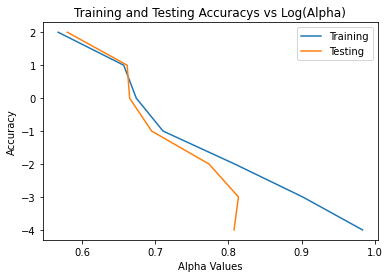

In [101]:
# starter code
import matplotlib.pyplot as plt

Acc_Train = []
Acc_Test = []
x_alpha = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0]
for i in x_alpha:
    classifier = SGDClassifier(loss='log', max_iter=1000, alpha=i, tol=1.0e-12, random_state=123, eta0=100, average=False)
    classifier.fit(X_train, Y_train)
    Acc_Train.append(accuracy_score(Y_train, classifier.predict(X_train)))
    Acc_Test.append(accuracy_score(Y_test, classifier.predict(X_test)))

plt.plot(Acc_Train, np.log10(x_alpha), label = "Training")
plt.plot(Acc_Test, np.log10(x_alpha), label = "Testing")
plt.xlabel('Alpha Values')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracys vs Log(Alpha)')
plt.legend()
plt.show()

#### Deliverable 3.2

Examine the classifier probabilities using the `predict_proba` function when training with different values of `alpha`. What do you observe? How does `alpha` affect the prediction probabilities, and why do you think this happens?

In [113]:
x_alpha = [0.0001,0.001,0.01,0.1,1.0,10.0,100.0]
for i in x_alpha:
    classifier = SGDClassifier(loss='log', max_iter=1000, alpha=i, tol=1.0e-12, random_state=123, eta0=100, average=False)
    classifier.fit(X_train, Y_train)
    print("Training Probabilities: Alpha = "+str(i)+":", classifier.predict_proba(X_train)[:5:,1])
    print("Testing Probabilities: Alpha = "+str(i)+":", classifier.predict_proba(X_test)[:5:,1])

Training Probabilities: Alpha = 0.0001: [0.8926483  0.92525664 0.95152051 ... 0.99023939 0.95121941 0.99617467]
Testing Probabilities: Alpha = 0.0001: [0.98501786 0.30769152 0.03490931 0.18867106 0.21789052]
Training Probabilities: Alpha = 0.001: [0.64678344 0.83130199 0.86297474 ... 0.96155927 0.81720322 0.96783101]
Testing Probabilities: Alpha = 0.001: [0.85944809 0.45328637 0.17753691 0.26668736 0.42549922]
Training Probabilities: Alpha = 0.01: [0.46370627 0.67364589 0.69961044 ... 0.81771378 0.67200993 0.81518575]
Testing Probabilities: Alpha = 0.01: [0.63139015 0.50315198 0.36695194 0.29859382 0.54190401]
Training Probabilities: Alpha = 0.1: [0.45318799 0.53082381 0.55456199 ... 0.55817342 0.53905657 0.58202761]
Testing Probabilities: Alpha = 0.1: [0.51681414 0.45997116 0.47153346 0.41762782 0.52435313]
Training Probabilities: Alpha = 1.0: [0.48540744 0.49758786 0.50508452 ... 0.4905263  0.50210389 0.50944965]
Testing Probabilities: Alpha = 1.0: [0.49996084 0.480459   0.49492718 0

[Looking at the resulting probabilities of the first 5 emails in both the training and testing data sets, it's apparent that as alpha increases, the training and testing probabilites both approach each other, and there appears to be a limit to a 50% probability for each tweet in both sets. This makes sense as each tweet is a boolean and can only be either referenceing a disaster or not, and as we increase alpha, the SGDClassifier begins to simply guess as to what tweet references what. Since alpha references the strength of the weights, eventually the model will recognize each weight as equal as alpha increases, and we see this reflected in the resulting tweet probabilities for both training and testing data. We want to choose an alpha for which the training and testing probabilies are the closest, but also have highest probabilities.]

#### Deliverable 3.3: 

Now remove the `alpha` argument so that it goes back to the default value. We'll now look at the effect of the learning rate. By default, `sklearn` uses an "optimal" learning rate based on some heuristics that work well for many problems. However, it can be good to see how the learning rate can affect the algorithm.

For this task, add the keyword argument `learning_rate` to the `SGDClassifier` function and set the value to `invscaling`. This defines the learning rate at iteration $t$ as: $\eta_t = \frac{\eta_0}{t^a}$, where $\eta_0$ and $a$ are both arguments you have to define in the `SGDClassifier` function, called `eta0` and `power_t`, respectively. Experiment with different values of `eta0` and `power_t` and see how they affect the number of iterations it takes the algorithm to converge. You will often find that it will not finish within the maximum of $1000$ iterations.

In [111]:
eta0_l = [10,100,1000,10000] 
power_tl = [0.5,1.0,2.0]
final_eta = []
final_power = []
final_iter = []
for i in eta0_l:
    for z in power_tl:
        classifier = SGDClassifier(loss='log', max_iter=1000, learning_rate = 'invscaling', tol=1.0e-12, random_state=123, eta0=i, power_t=z, average=False)
        classifier.fit(X_train, Y_train)
        final_eta.append(i)
        final_power.append(z)
        final_iter.append(classifier.n_iter_)
        
final_df = pd.DataFrame(zip(final_eta,final_power,final_iter))
final_df.columns = ['eta0','power_t','iter']

C:\Users\ryer7052\Anaconda3\envs\ML\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:574: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
C:\Users\ryer7052\Anaconda3\envs\ML\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:574: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
C:\Users\ryer7052\Anaconda3\envs\ML\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:574: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
C:\Users\ryer7052\Anaconda3\envs\ML\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:574: ConvergenceWarning: Max

Fill in the table below with the number of iterations for values of `eta0` in $[10.0, 100.0, 1000.0, 10000.0]$ and values of `power_t` in $[0.5, 1.0, 2.0]$. You may find it easier to write python code that can output the markdown for the table, but if you do that place the output here. If it does not converge within the maximum number of iterations (set to $1000$ by `max_iter`), record $1000$ as the number of iterations. You will need to read the documentation for this class to learn how to recover the actual number of iterations before reaching the stopping criterion.

In [110]:
final_df

,eta0,power_t,iter
0,10,0.5,177
1,10,1.0,1000
2,10,2.0,1000
3,100,0.5,94
4,100,1.0,1000
5,100,2.0,1000
6,1000,0.5,105
7,1000,1.0,1000
8,1000,2.0,1000
9,10000,0.5,70


#### Deliverable 3.4

Describe how `eta0` and `power_t` affect the learning rate based on the formula (e.g., if you increase `power_t`, what will this do to the learning rate?), and connect this to what you observe in the table above.

[Eta seems to have more of an impact on the data than power_t, this makes sense since in the new learning rate is eta/power_t. In our loops, power t is essentially the impact on the learning rate, and the actualy learnin rate can be thought of as eta. The first iteration of power_t always doubles eta, then as power_t increases, eta becomes eta, and then eta/2. As the learning rate increases, the max number of iterations needed to find the correct weights tends to decrease. We can see this trend in the graph, with eta0=10000 and power_t=0.5 having the least amount of iterations. With the learning rate being $\eta_t = \frac{\eta_0}{t^a}$, we can also see this is the largest learning rate in our trials.]

Now remove the `learning_rate`, `eta0`, and `power_t` arguments so that the learning rate returns to the default setting. For this final task, we will experiment with how high the probabiity must be before an instance is classified as positive.

The code below includes a function called `threshold` which takes as input the classification probabilities of the data (called `probs`, which is given by the function `predict_proba`) and a threshold (called `tau`, a scalar that should be a value between $0$ and $1$). It will classify each instance as $1$ if the probability of being $1$ is greater than `tau`, otherwise it will classify the instance as $0$. Note that if you set `tau` to $0.5$, the `threshold` function should give you exactly the same output as the classifier `predict` function.

You should find that increasing the threshold causes the accuracy to drop. This makes sense, because you are classifying some things as 0 even though it's more probable that they are 1. So why do this? Suppose you care more about accurately identifying tweets about natural disasters than missing tweets about disasters (e.g. maybe you forward these tweets to first responders.) You thus want to be confident that when you classify a tweet as 1 that it really is 1.

There is a metric called _precision_ which measures something like accuracy but for one specific class. Whereas accuracy is the percentage of tweets that were correctly classified, the precision of 1 would be the percentage of tweets classified as 1 that were correctly classified. (In other words, the number of tweets classified as 1 whose correct label was 1, divided by the number of tweets classified as 1.)

You can use the [`precision_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score) function from `sklearn` to calculate the precision. It works much like the `accuracy_score` function.

#### Deliverable 3.5

Calculate the testing precision when the value of `tau` for thresholding is one of $[0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]$. Create a plot where the x-axis is `tau` and the y-axis is precision.

[your solution should be plotted below]

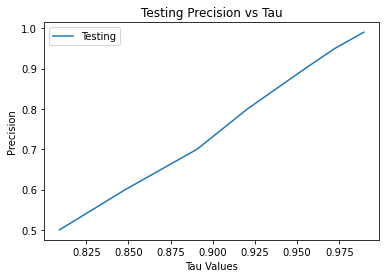

In [126]:
# use this function for deliverable 3.5
def threshold(probs, tau):
    return np.where(probs[:,1] > tau, 1, 0)

# your logistic regression code here
classifier = SGDClassifier(loss='log', max_iter=1000, tol=1.0e-12, random_state=123)
classifier.fit(X_train, Y_train)
tau_l = [0.5,0.6,0.7,0.8,0.9,0.95,0.99]
per_score_test = []
for i in tau_l:
    var = threshold(classifier.predict_proba(X_test), i)
    per_score_test.append(precision_score(Y_test, var))

plt.plot(per_score_test, tau_l, label = "Testing")
plt.xlabel('Tau Values')
plt.ylabel('Precision')
plt.title('Testing Precision vs Tau')
plt.legend()
plt.show()

#### Deliverable 3.6

Describe what you observe with thresholding (e.g., what happens to precision as the threshold increases?), and explain why you think this happens.

[As tau increases, the precision of our data increases. This makes sense, since as we increase tau, we are also increasing the probability we want to use for returning a tweet that is actually about disasters. As this gets stricter, we begin to get rid of tweets that have a 70%, 80%, and even 90% probability that they are referencing disasters. As we increase the threshold for returning a correct tweet, we see an increase in precision, but we should also see a decrease in the actual number of tweets returned.]

## Problem 4: Sparse learning [5604: 5 points; 4604: +3 EC points]

Add the `penalty` argument to `SGDClassifier` and set the value to `'l1'`, which tells the algorithm to use L1 regularization instead of the default L2. Recall from lecture that L1 regularization encourages weights to stay at exactly $0$, resulting in a more "sparse" model than L2. You should see this effect if you examine the values of `classifier.coef_`.

#### Deliverable 4.1: 

Write a function to calculate the number of features whose weights are nonzero when using L1 regularization. Calculate the number of nonzero feature weights when `alpha` is one of $[0.00001, 0.0001, 0.001, 0.01, 0.1]$. Create a plot where the x-axis is `alpha` and the y-axis is the number of nonzero weights, using a log scale for the x-axis.

[your solution should be plotted below]

C:\Users\ryer7052\Anaconda3\envs\ML\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:574: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn("Maximum number of iteration reached before "
No handles with labels found to put in legend.


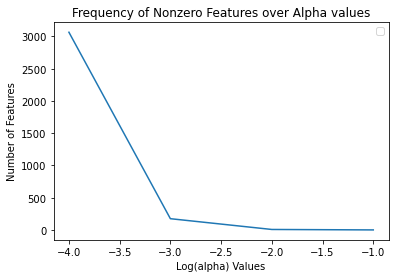

In [173]:
# your code here
x_alpha = [0.0001,0.001,0.01,0.1]
coef = []
for i in x_alpha:
    classifier = SGDClassifier(loss='log', max_iter=10000, alpha=i, tol=1.0e-12, random_state=123, eta0=100, average=False, penalty = 'l1')
    classifier.fit(X_train, Y_train)
    coef.append(np.count_nonzero(classifier.coef_))
    
plt.plot(np.log10(x_alpha),coef)
plt.xlabel('Log(alpha) Values')
plt.ylabel('Number of Features')
plt.title('Frequency of Nonzero Features over Alpha values')
plt.legend()
plt.show()

[Briefly explain your plot in a few sentences. What happens as you increase `alpha`; does that make sense?]

There seems to be an overall negative relationship between the number of nonzero features and alpha, which makes sense since as we've seen in the past, as we increase alpha we area also increasing the strength of the weights, which means that each coefficient should eventually have an impact on the data set. As this increases, the SGDClassifier begins to place equal importance on all weights, and will eventually not beable to discern which ones affect the data, since eventually they would all affect the data the same, this is the same reasoning the probabilities of placing a tweet into one of the two classes converges to 50/50, as at that point perceptron begins to essentually "guess" which class the tweet in quesiton should go into. 